In [1]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\Hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Path to dataset files:", path)
df.head()

Path to dataset files: C:\Users\Hp\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df = df.drop(columns=['customerID'])

In [7]:
from sklearn.preprocessing import LabelEncoder
  
categorical_cols = df.select_dtypes(include=['object']).columns
label = LabelEncoder()
for col in categorical_cols:
    if df[col].dtype == 'object':
        df[col] = label.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1


In [8]:
x = df.drop(columns=['Churn']).values
y = df['Churn'].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train[:5], y_test[:5]  

(array([[-1.02516569e+00, -4.37749204e-01, -9.69578591e-01,
          1.53218588e+00, -4.65683364e-01,  3.29573443e-01,
         -1.00053704e+00, -1.18234670e+00,  1.41087932e+00,
         -1.03835668e+00,  1.24865826e+00, -9.21483507e-01,
         -1.11746144e+00,  1.13423428e+00,  3.72908354e-01,
         -1.20000722e+00,  1.33926673e+00, -4.73723375e-04,
         -1.40800618e+00],
        [-1.02516569e+00, -4.37749204e-01, -9.69578591e-01,
         -6.52662324e-01,  8.85536787e-01,  3.29573443e-01,
          1.10833901e+00,  1.74618326e-01, -9.15399313e-01,
          1.23000375e+00, -1.02360939e+00, -9.21483507e-01,
          1.14070848e+00,  1.13423428e+00,  1.57759050e+00,
          8.33328321e-01, -1.47094882e+00,  1.07475386e+00,
          5.58360318e-01],
        [ 9.75452077e-01, -4.37749204e-01,  1.03137591e+00,
         -6.52662324e-01, -1.28460467e+00, -3.03422506e+00,
          5.39009851e-02, -1.18234670e+00, -9.15399313e-01,
         -1.03835668e+00, -1.02360939e+00, -9.

In [10]:
knn = KNeighborsClassifier(n_neighbors=10) # 1, 3, 5, 7, 10
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1409,))

In [11]:
accuracy_score(y_test, y_pred)

0.7757274662881476

In [12]:
confusion_matrix(y_test, y_pred)

array([[931, 105],
       [211, 162]])

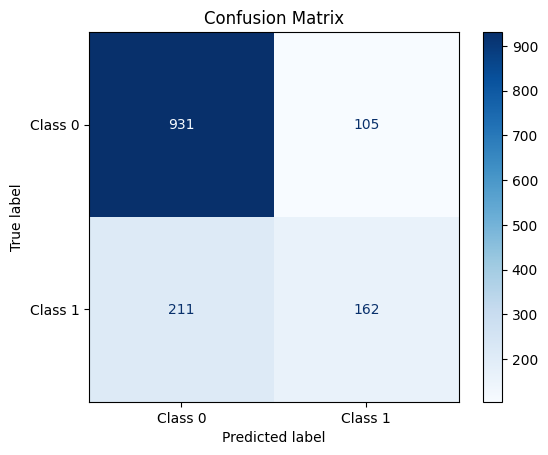

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues) # You can choose other colormaps
plt.title('Confusion Matrix')
plt.show()